# Prédiction de la qualité de taille (`cut`) des diamants — Modèle **Naïve Bayes SOUS-AJUSTÉ (Underfit)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
MODELS_DIR = "."
os.makedirs(MODELS_DIR, exist_ok=True)


## 1. Chargement des données

In [2]:
df = pd.read_csv("diamonds.csv", index_col=0)
print("Dimensions brutes :", df.shape)
df.head()


Dimensions brutes : (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2. Nettoyage

Les colonnes `x`, `y`, `z` représentent les dimensions physiques du diamant (en mm). Une valeur de **0** est physiquement impossible et correspond à une erreur de saisie : ces lignes sont supprimées. On supprime également les doublons.

In [3]:
avant = df.shape[0]
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]
df = df.drop_duplicates()
print(f"Lignes supprimées : {avant - df.shape[0]}")
print("Dimensions après nettoyage :", df.shape)


Lignes supprimées : 165
Dimensions après nettoyage : (53775, 10)


## 3. Encodage des variables

- `color` et `clarity` sont des variables **catégorielles ordinales** (il existe un ordre naturel de qualité). On les encode donc par un **encodage ordinal** (0 = pire, valeur max = meilleur), et non par one-hot, afin de conserver l'information d'ordre.
- La cible `cut` est également ordinale (Fair < Good < Very Good < Premium < Ideal). On l'encode dans cet ordre pour que les matrices de confusion et rapports soient lisibles, mais le problème reste traité comme une **classification multi-classes** (5 classes), conformément à la consigne.

In [4]:
color_order = ["J", "I", "H", "G", "F", "E", "D"]          # J = pire couleur -> D = meilleure couleur
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]  # I1 = pire -> IF = meilleure
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]

df["color_enc"] = df["color"].map({c: i for i, c in enumerate(color_order)})
df["clarity_enc"] = df["clarity"].map({c: i for i, c in enumerate(clarity_order)})
df["cut_enc"] = df["cut"].map({c: i for i, c in enumerate(cut_order)})

df[["color", "color_enc", "clarity", "clarity_enc", "cut", "cut_enc"]].head()


,color,color_enc,clarity,clarity_enc,cut,cut_enc
1,E,5,SI2,1,Ideal,4
2,E,5,SI1,2,Premium,3
3,E,5,VS1,4,Good,1
4,I,1,VS2,3,Premium,3
5,J,0,SI2,1,Good,1


## 4. Séparation train / test

In [5]:
y_full = df["cut_enc"].values

train_pool_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

train_pool = df.loc[train_pool_idx].copy()
test = df.loc[test_idx].copy()

print("Train pool :", train_pool.shape)
print("Test       :", test.shape)
print()
print("Répartition des classes (test) :")
print(test["cut"].value_counts(normalize=True).round(3))


Train pool : (43020, 13)
Test       : (10755, 13)

Répartition des classes (test) :
cut
Ideal        0.400
Premium      0.255
Very Good    0.224
Good         0.091
Fair         0.030
Name: proportion, dtype: float64


## 5. Quelle variable pour provoquer un sous-apprentissage ?

On calcule l'**information mutuelle** entre chaque variable numérique/ordinale et la cible `cut`. Une information mutuelle proche de 0 signifie que la variable n'apporte presque aucune information sur la classe.

In [6]:
features_all = ["carat", "depth", "table", "price", "x", "y", "z", "color_enc", "clarity_enc"]
mi = mutual_info_classif(train_pool[features_all], train_pool["cut_enc"], random_state=RANDOM_STATE)

mi_df = pd.DataFrame({"variable": features_all, "information_mutuelle": mi}).sort_values(
    "information_mutuelle", ascending=False
).reset_index(drop=True)
mi_df


,variable,information_mutuelle
0,depth,0.360267
1,table,0.324272
2,x,0.097661
3,price,0.096731
4,y,0.082386
5,carat,0.072604
6,z,0.069194
7,clarity_enc,0.033221
8,color_enc,0.003127


C:\Users\NICK-TECH\AppData\Local\Temp\ipykernel_14080\909719796.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="information_mutuelle", y="variable", palette="viridis")


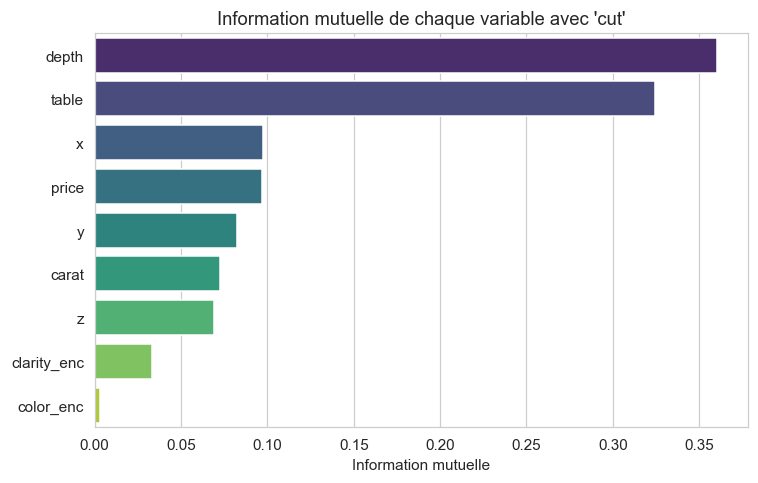

In [7]:
plt.figure(figsize=(7, 4.5))
sns.barplot(data=mi_df, x="information_mutuelle", y="variable", palette="viridis")
plt.title("Information mutuelle de chaque variable avec 'cut'")
plt.xlabel("Information mutuelle")
plt.ylabel("")
plt.tight_layout()
plt.savefig("./underfit_mutual_info.png", dpi=110)
plt.show()


**Constat :** `color` et `clarity` sont, de loin, les variables les **moins informatives** pour prédire `cut` (à l'inverse de `depth` et `table`, qui sont très informatives car la qualité de taille est historiquement définie à partir des proportions du diamant). On choisit donc délibérément **`color_enc` et `clarity_enc`** comme unique base du modèle sous-ajusté.

## 6. Construction du modèle sous-ajusté

- Variables : `color_enc`, `clarity_enc` uniquement (peu informatives)
- `var_smoothing = 1.0` (valeur énorme par rapport à la valeur par défaut `1e-9`) → sur-lissage extrême des distributions gaussiennes par classe
- Entraînement sur l'intégralité du train pool (~80 % des données)

In [8]:
FEATURES_UNDERFIT = ["color_enc", "clarity_enc"]

X_train = train_pool[FEATURES_UNDERFIT]
y_train = train_pool["cut_enc"]
X_test = test[FEATURES_UNDERFIT]
y_test = test["cut_enc"]

scaler_underfit = StandardScaler().fit(X_train)
X_train_sc = scaler_underfit.transform(X_train)
X_test_sc = scaler_underfit.transform(X_test)

nb_underfit = GaussianNB(var_smoothing=1.0)
nb_underfit.fit(X_train_sc, y_train)

print("Modèle entraîné :", nb_underfit)


Modèle entraîné : GaussianNB(var_smoothing=1.0)


## 7. Évaluation du modèle

In [9]:
y_pred_train = nb_underfit.predict(X_train_sc)
y_pred_test = nb_underfit.predict(X_test_sc)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy TRAIN : {acc_train:.4f}")
print(f"Accuracy TEST  : {acc_test:.4f}")
print(f"Écart train-test : {acc_train - acc_test:+.4f}")


Accuracy TRAIN : 0.3997
Accuracy TEST  : 0.4000
Écart train-test : -0.0003


In [10]:
print(classification_report(y_test, y_pred_test, target_names=cut_order))


              precision    recall  f1-score   support

        Fair       0.00      0.00      0.00       319
        Good       0.00      0.00      0.00       978
   Very Good       0.00      0.00      0.00      2414
     Premium       0.40      0.00      0.00      2747
       Ideal       0.40      1.00      0.57      4297

    accuracy                           0.40     10755
   macro avg       0.16      0.20      0.12     10755
weighted avg       0.26      0.40      0.23     10755



c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

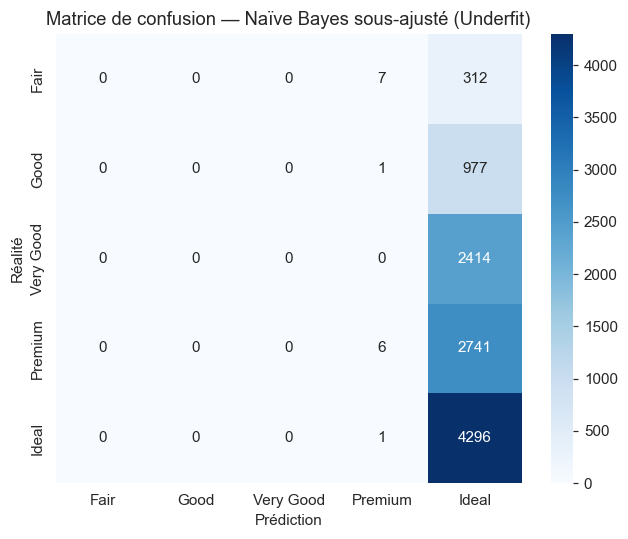

In [11]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cut_order, yticklabels=cut_order)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion — Naïve Bayes sous-ajusté (Underfit)")
plt.tight_layout()
plt.savefig("./underfit_confusion_matrix.png", dpi=110)
plt.show()


## 8. Interprétation

- L'accuracy **train** et **test** sont proches l'une de l'autre (faible écart), mais **toutes deux basses**.
- Le modèle ne dispose pas d'assez d'information (seulement `color` et `clarity`, peu corrélées à `cut`) et le sur-lissage (`var_smoothing=1.0`) l'empêche de bien discriminer les classes.
- Ce comportement — **biais élevé, variance faible** — est la signature typique du **sous-apprentissage (underfitting)**.
- Sans surprise, la matrice de confusion montre que le modèle prédit très majoritairement les classes les plus fréquentes (Ideal, Premium) quel que soit le diamant réellement observé.

## 9. Sauvegarde des artefacts pour l'application Streamlit

In [12]:
joblib.dump(nb_underfit, os.path.join(MODELS_DIR, "nb_underfit.pkl"))
joblib.dump(scaler_underfit, os.path.join(MODELS_DIR, "scaler_underfit.pkl"))

metrics_underfit = {
    "nom": "Naive Bayes - Sous-ajuste (Underfit)",
    "features": FEATURES_UNDERFIT,
    "var_smoothing": 1.0,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "accuracy_train": float(acc_train),
    "accuracy_test": float(acc_test),
    "ecart_train_test": float(acc_train - acc_test),
    "classification_report": classification_report(y_test, y_pred_test, target_names=cut_order, output_dict=True),
    "confusion_matrix": cm.tolist(),
    "cut_order": cut_order,
    "color_order": color_order,
    "clarity_order": clarity_order,
}

with open(os.path.join(MODELS_DIR, "metrics_underfit.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_underfit, f, ensure_ascii=False, indent=2)

print("Artefacts sauvegardes dans", MODELS_DIR)
print(" - nb_underfit.pkl")
print(" - scaler_underfit.pkl")
print(" - metrics_underfit.json")


Artefacts sauvegardes dans .
 - nb_underfit.pkl
 - scaler_underfit.pkl
 - metrics_underfit.json


c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\NICK-TECH\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf